# 🧹 Step 2 — Preprocessing

**เป้าหมาย:** เตรียมข้อมูลให้พร้อมก่อนใส่โมเดล  

| Concept | สิ่งที่จะทำ |
|---|---|
| **Imputation** | เติมค่าที่หายไป (ค่า 0 ที่เป็นไปไม่ได้) |
| **Train/Test Split** | แบ่งข้อมูลเพื่อทดสอบโมเดลอย่างยุติธรรม |
| **Feature Scaling** | ทำให้ทุก feature อยู่ในสเกลเดียวกัน |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. โหลดข้อมูล

In [3]:
df = pd.read_csv("diabetes.csv")
print(f"size: {df.shape}")
df.head()

size: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,2.0,116.0,71.0,48.0,1.0,20.3,0.150,41.0,0.0
1,1.0,144.0,0.0,16.0,15.0,28.9,0.605,37.0,1.0
2,4.0,95.0,83.0,15.0,19.0,36.7,0.080,24.0,0.0
3,3.0,199.0,55.0,0.0,0.0,43.9,0.998,31.0,1.0
4,3.0,159.0,60.0,22.0,23.0,43.5,0.080,30.0,1.0


## 3. Imputation — เติมค่าที่หายไป

> **ทำไมใช้ Median?** ทนทานต่อ outlier กว่า Mean  
> **ทำไมแยกตาม Class?** คนเป็น/ไม่เป็นเบาหวานมีค่าเฉลี่ย Glucose ต่างกันมาก ถ้าเติมค่าเดียวกันทั้งหมด = ใส่ bias ผิดๆ

In [4]:
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# ก่อน imputation
print("ค่า 0 ก่อน Imputation:")
print((df[cols_to_fix] == 0).sum().to_string())

ค่า 0 ก่อน Imputation:
Glucose            0
BloodPressure     26
SkinThickness    230
Insulin          381
BMI                0


In [5]:
df_clean = df.copy()

for col in cols_to_fix:
    for outcome_val in [0, 1]:
        mask_valid   = (df_clean[col] != 0) & (df_clean["Outcome"] == outcome_val)
        median_val   = df_clean.loc[mask_valid, col].median()
        mask_replace = (df_clean[col] == 0) & (df_clean["Outcome"] == outcome_val)
        df_clean.loc[mask_replace, col] = median_val

print("ค่า 0 หลัง Imputation (ควรเป็น 0 ทุกตัว ✓):")
print((df_clean[cols_to_fix] == 0).sum().to_string())

ค่า 0 หลัง Imputation (ควรเป็น 0 ทุกตัว ✓):
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0


### Visualize: ก่อน vs หลัง Imputation

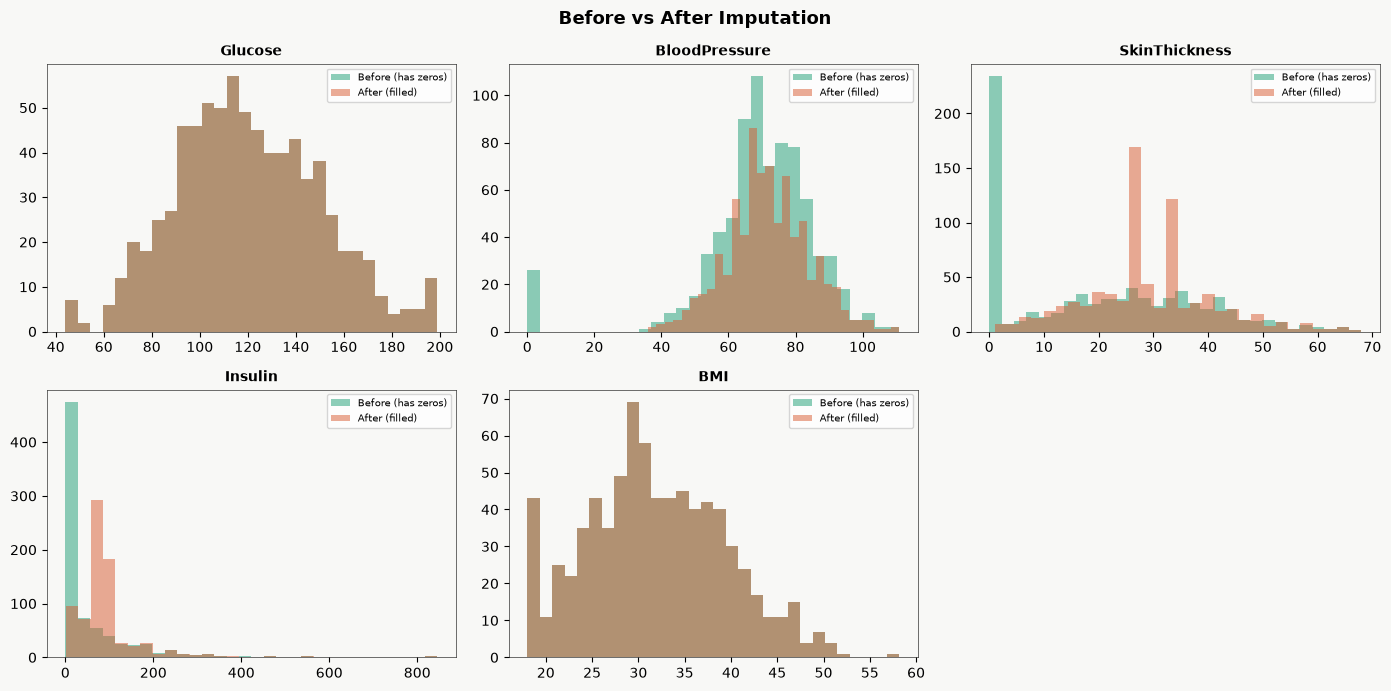

Saved: step2_imputation.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor("#F8F8F6")
fig.suptitle("Before vs After Imputation", fontsize=13, fontweight="bold")

for i, col in enumerate(cols_to_fix):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col],       bins=30, alpha=0.5, color="#1D9E75", label="Before (has zeros)")
    ax.hist(df_clean[col], bins=30, alpha=0.5, color="#D85A30", label="After (filled)")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.set_facecolor("#F8F8F6")
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig("step2_imputation.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step2_imputation.png")

## 4. Train / Test Split

> **ทำไมต้องแบ่ง?** จำลองสถานการณ์จริง — โมเดลไม่ควร "เห็น" ข้อมูล test ล่วงหน้า เหมือนสอบด้วยข้อสอบที่ไม่เคยเห็นมาก่อน  
> **stratify=y** → รักษาสัดส่วน class ให้เท่ากันใน train และ test

In [7]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} แถว  |  สัดส่วนเบาหวาน: {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]}  แถว  |  สัดส่วนเบาหวาน: {y_test.mean():.1%}")
print("\n→ สัดส่วนใกล้เคียงกัน = stratify ทำงานถูกต้อง ✓")

Train : 614 แถว  |  สัดส่วนเบาหวาน: 35.0%
Test  : 154  แถว  |  สัดส่วนเบาหวาน: 35.1%

→ สัดส่วนใกล้เคียงกัน = stratify ทำงานถูกต้อง ✓


## 5. Feature Scaling (StandardScaler)

> **ปัญหา:** Insulin มีค่า 0–800+ ส่วน Pregnancies มีค่า 0–17 โมเดลจะคิดว่า Insulin "สำคัญกว่า" แค่เพราะตัวเลขใหญ่กว่า  
> **StandardScaler** แปลงให้ทุก feature มี mean=0, std=1  
> ⚠️ **fit บน train เท่านั้น** → ป้องกัน Data Leakage

In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # เรียนรู้ mean/std จาก train
    columns=X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),        # ใช้ mean/std เดิม (ห้าม fit ใหม่)
    columns=X.columns
)

print("Mean หลัง Scaling (ควรใกล้ 0 ✓):")
print(X_train_scaled.mean().round(4).to_string())

Mean หลัง Scaling (ควรใกล้ 0 ✓):
Pregnancies        -0.0
Glucose             0.0
BloodPressure      -0.0
SkinThickness       0.0
Insulin            -0.0
BMI                 0.0
DiabetesPedigree    0.0
Age                -0.0


In [9]:
print("ตัวอย่างข้อมูลหลัง Scaling (3 แถวแรก):")
X_train_scaled.head(3).round(3)

ตัวอย่างข้อมูลหลัง Scaling (3 แถวแรก):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age
0,0.560,1.242,-0.380,-0.253,-0.342,1.773,-0.089,-0.653
1,-1.117,0.878,-0.380,-1.890,-0.796,-0.312,-0.839,-0.443
2,0.560,2.567,-1.267,0.523,-0.830,-0.391,0.149,-0.023


## 6. บันทึกไฟล์สำหรับ Step 3

In [10]:
X_train_scaled.to_csv("X_train.csv", index=False)
X_test_scaled.to_csv("X_test.csv",   index=False)
y_train.to_csv("y_train.csv",        index=False)
y_test.to_csv("y_test.csv",          index=False)

print("✅ บันทึกแล้ว: X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("→ พร้อมสำหรับ Step 3: Model Training")

✅ บันทึกแล้ว: X_train.csv, X_test.csv, y_train.csv, y_test.csv
→ พร้อมสำหรับ Step 3: Model Training
